# Transformer-Based Text Classification using DistilBERT and BERT

This notebook implements transformer-based deep learning models for SMS spam detection. Unlike traditional machine learning approaches that rely on manually engineered features such as TF-IDF vectors, transformer models learn contextual representations of text through self-attention mechanisms.

Two transformer architectures were evaluated:

1. DistilBERT
2. BERT Base Uncased

The objective was to determine whether transformer-based models could improve spam classification performance compared to the traditional machine learning and recurrent neural network models developed in previous notebooks.

In [1]:
import pandas as pd
import numpy as np

import torch

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import evaluate

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

CUDA Available: True
NVIDIA GeForce RTX 4070 Laptop GPU


In [3]:
train_df = pd.read_csv(
    "../data/processed/train.csv"
)

val_df = pd.read_csv(
    "../data/processed/val.csv"
)

test_df = pd.read_csv(
    "../data/processed/test.csv"
)

In [4]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

train_df.head()

(3614, 6)
(774, 6)
(775, 6)


,label,text,char_count,word_count,clean_text,target
0,spam,GENT! We are trying to contact you. Last weeke...,160,27,gent trying contact last weekend draw show å£ ...,1
1,spam,FREEMSG: Our records indicate you may be entit...,157,31,freemsg record indicate may entitled pound acc...,1
2,ham,What is important is that you prevent dehydrat...,77,13,important prevent dehydration giving enough fluid,0
3,ham,Lol yes. But it will add some spice to your day.,48,11,lol yes add spice day,0
4,ham,HI ITS KATE CAN U GIVE ME A RING ASAP XXX,41,11,hi kate u give ring asap xxx,0


In [5]:
train_df = train_df[
    ["clean_text", "target"]
]

val_df = val_df[
    ["clean_text", "target"]
]

test_df = test_df[
    ["clean_text", "target"]
]

In [6]:
train_df = train_df.dropna()

val_df = val_df.dropna()

test_df = test_df.dropna()

In [7]:
train_df = train_df.rename(
    columns={
        "target":"label"
    }
)

val_df = val_df.rename(
    columns={
        "target":"label"
    }
)

test_df = test_df.rename(
    columns={
        "target":"label"
    }
)

In [8]:
train_ds = Dataset.from_pandas(
    train_df
)

val_ds = Dataset.from_pandas(
    val_df
)

test_ds = Dataset.from_pandas(
    test_df
)

## Transformer Tokenization

Transformer models cannot directly process raw text. Therefore, text messages were converted into token sequences using the tokenizer associated with each pretrained model.

The tokenizer performs:

- Text normalization
- Subword tokenization
- Vocabulary mapping
- Attention mask generation

Maximum sequence length was fixed to ensure consistent input dimensions across all samples.

In [9]:
model_checkpoint = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    model_checkpoint
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [10]:
def tokenize_function(example):

    return tokenizer(

        example["clean_text"],

        truncation=True,

        padding="max_length",

        max_length=128

    )

In [11]:
train_ds = train_ds.map(
    tokenize_function,
    batched=True
)

val_ds = val_ds.map(
    tokenize_function,
    batched=True
)

test_ds = test_ds.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/3614 [00:00<?, ? examples/s]

Map:   0%|          | 0/774 [00:00<?, ? examples/s]

Map:   0%|          | 0/775 [00:00<?, ? examples/s]

In [12]:
train_ds = train_ds.remove_columns(
    ["clean_text"]
)

val_ds = val_ds.remove_columns(
    ["clean_text"]
)

test_ds = test_ds.remove_columns(
    ["clean_text"]
)

## HuggingFace Dataset Creation

The tokenized data was converted into HuggingFace Dataset objects.

This format enables:

- Efficient batching
- GPU acceleration
- Seamless integration with the HuggingFace Trainer API
- Automatic metric evaluation during training

The train, validation, and test datasets were prepared separately.

In [13]:
train_ds.set_format(
    "torch"
)

val_ds.set_format(
    "torch"
)

test_ds.set_format(
    "torch"
)

In [14]:
accuracy_metric = evaluate.load(
    "accuracy"
)

precision_metric = evaluate.load(
    "precision"
)

recall_metric = evaluate.load(
    "recall"
)

f1_metric = evaluate.load(
    "f1"
)

## Evaluation Metrics

Model performance was evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score

Although accuracy provides an overall measure of correctness, F1 Score was treated as the primary evaluation metric because the SMS Spam dataset is moderately imbalanced and spam detection requires balancing precision and recall.

In [15]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )

    precision = precision_metric.compute(
        predictions=predictions,
        references=labels
    )

    recall = recall_metric.compute(
        predictions=predictions,
        references=labels
    )

    f1 = f1_metric.compute(
        predictions=predictions,
        references=labels
    )

    return {

        "accuracy": accuracy["accuracy"],

        "precision": precision["precision"],

        "recall": recall["recall"],

        "f1": f1["f1"]

    }

## DistilBERT Fine-Tuning

DistilBERT is a compressed version of BERT that retains much of BERT's language understanding capability while reducing model size and computational requirements.

The pretrained DistilBERT model was loaded and fine-tuned on the SMS spam classification task using supervised learning.

In [16]:
distilbert_model = AutoModelForSequenceClassification.from_pretrained(

    model_checkpoint,

    num_labels=2

)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [17]:
training_args = TrainingArguments(

    output_dir="../models/distilbert_output",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=5,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    logging_dir="../logs",

    report_to="none"

)

In [18]:
trainer = Trainer(

    model=distilbert_model,

    args=training_args,

    train_dataset=train_ds,

    eval_dataset=val_ds,

    compute_metrics=compute_metrics,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]

)

In [19]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.058614,0.985788,0.948454,0.938776,0.943590
2,No log,0.080772,0.983204,0.947368,0.918367,0.932642
3,0.087200,0.072275,0.985788,0.930693,0.959184,0.944724
4,0.087200,0.094117,0.983204,0.967033,0.897959,0.931217
5,0.018900,0.089574,0.981912,0.956522,0.897959,0.926316


TrainOutput(global_step=1130, training_loss=0.04853118014546622, metrics={'train_runtime': 130.8978, 'train_samples_per_second': 138.047, 'train_steps_per_second': 8.633, 'total_flos': 598421473428480.0, 'train_loss': 0.04853118014546622, 'epoch': 5.0})

## DistilBERT Training Analysis

The DistilBERT model converged successfully during fine-tuning.

Validation performance remained stable throughout training, indicating that the pretrained language representations adapted effectively to the spam classification task.

The model achieved strong spam detection capability and demonstrated the effectiveness of transformer architectures even on relatively small text classification datasets.

In [20]:
trainer.evaluate()

{'eval_loss': 0.07227528840303421,
 'eval_accuracy': 0.9857881136950905,
 'eval_precision': 0.9306930693069307,
 'eval_recall': 0.9591836734693877,
 'eval_f1': 0.9447236180904522,
 'eval_runtime': 1.6086,
 'eval_samples_per_second': 481.175,
 'eval_steps_per_second': 30.462,
 'epoch': 5.0}

In [21]:
predictions = trainer.predict(
    test_ds
)

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

y_true = test_df["label"].values

In [22]:
print(

    classification_report(
        y_true,
        y_pred
    )

)

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       677
           1       0.85      0.96      0.90        98

    accuracy                           0.97       775
   macro avg       0.92      0.97      0.94       775
weighted avg       0.98      0.97      0.97       775



In [23]:
distilbert_accuracy = accuracy_score(
    y_true,
    y_pred
)

distilbert_precision = precision_score(
    y_true,
    y_pred
)

distilbert_recall = recall_score(
    y_true,
    y_pred
)

distilbert_f1 = f1_score(
    y_true,
    y_pred
)

print("Accuracy :", distilbert_accuracy)
print("Precision:", distilbert_precision)
print("Recall   :", distilbert_recall)
print("F1 Score :", distilbert_f1)

Accuracy : 0.9729032258064516
Precision: 0.8468468468468469
Recall   : 0.9591836734693877
F1 Score : 0.8995215311004785


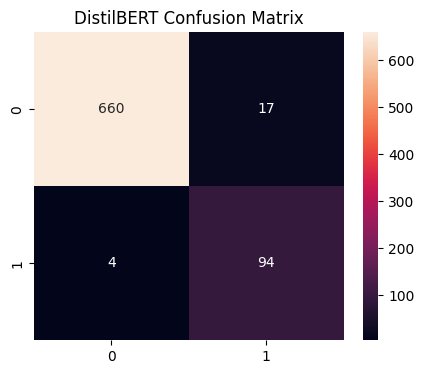

In [24]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "DistilBERT Confusion Matrix"
)

plt.savefig(
    "../results/figures/distilbert_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

## DistilBERT Results

Final DistilBERT Performance:

- Accuracy = 97.29%
- Precision = 84.68%
- Recall = 95.92%
- F1 Score = 89.95%

The high recall indicates that DistilBERT successfully identified most spam messages. However, the lower precision suggests that some legitimate messages were incorrectly classified as spam.

The confusion matrix confirms that the model prioritizes spam detection, resulting in a small increase in false positive predictions.

In [25]:
trainer.save_model(
    "../models/distilbert"
)

tokenizer.save_pretrained(
    "../models/distilbert"
)

('../models/distilbert\\tokenizer_config.json',
 '../models/distilbert\\special_tokens_map.json',
 '../models/distilbert\\vocab.txt',
 '../models/distilbert\\added_tokens.json',
 '../models/distilbert\\tokenizer.json')

In [26]:
distilbert_results = pd.DataFrame({

    "Model":["DistilBERT"],

    "Accuracy":[distilbert_accuracy],

    "Precision":[distilbert_precision],

    "Recall":[distilbert_recall],

    "F1":[distilbert_f1]

})

distilbert_results

,Model,Accuracy,Precision,Recall,F1
0,DistilBERT,0.972903,0.846847,0.959184,0.899522


## BERT Fine-Tuning

BERT Base Uncased was selected as a larger transformer architecture for comparison with DistilBERT.

BERT contains significantly more parameters and generally provides stronger contextual language understanding. The model was initialized using pretrained weights and then fine-tuned on the SMS spam classification dataset.

In [27]:
bert_checkpoint = "bert-base-uncased"

bert_tokenizer = AutoTokenizer.from_pretrained(
    bert_checkpoint
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [28]:
def bert_tokenize_function(example):

    return bert_tokenizer(

        example["clean_text"],

        truncation=True,

        padding="max_length",

        max_length=128

    )

In [29]:
train_df = pd.read_csv(
    "../data/processed/train.csv"
)

val_df = pd.read_csv(
    "../data/processed/val.csv"
)

test_df = pd.read_csv(
    "../data/processed/test.csv"
)

train_df = train_df[
    ["clean_text","target"]
]

val_df = val_df[
    ["clean_text","target"]
]

test_df = test_df[
    ["clean_text","target"]
]

train_df = train_df.rename(
    columns={"target":"label"}
)

val_df = val_df.rename(
    columns={"target":"label"}
)

test_df = test_df.rename(
    columns={"target":"label"}
)

In [30]:
bert_train_ds = Dataset.from_pandas(
    train_df
)

bert_val_ds = Dataset.from_pandas(
    val_df
)

bert_test_ds = Dataset.from_pandas(
    test_df
)

In [31]:
bert_train_ds = bert_train_ds.map(
    bert_tokenize_function,
    batched=True
)

bert_val_ds = bert_val_ds.map(
    bert_tokenize_function,
    batched=True
)

bert_test_ds = bert_test_ds.map(
    bert_tokenize_function,
    batched=True
)

Map:   0%|          | 0/3614 [00:00<?, ? examples/s]

Map:   0%|          | 0/774 [00:00<?, ? examples/s]

Map:   0%|          | 0/775 [00:00<?, ? examples/s]

In [32]:
bert_train_ds = bert_train_ds.remove_columns(
    ["clean_text"]
)

bert_val_ds = bert_val_ds.remove_columns(
    ["clean_text"]
)

bert_test_ds = bert_test_ds.remove_columns(
    ["clean_text"]
)

In [33]:
bert_train_ds.set_format("torch")
bert_val_ds.set_format("torch")
bert_test_ds.set_format("torch")

In [34]:
bert_model = AutoModelForSequenceClassification.from_pretrained(

    bert_checkpoint,

    num_labels=2

)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Error while downloading from https://huggingface.co/bert-base-uncased/resolve/main/model.safetensors: HTTPSConnectionPool(host='cas-bridge.xethub.hf.co', port=443): Read timed out.
Trying to resume download...


model.safetensors:  90%|######### | 398M/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [35]:
bert_training_args = TrainingArguments(

    output_dir="../results/bert",

    eval_strategy="epoch",

    save_strategy="epoch",

    logging_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    num_train_epochs=5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    weight_decay=0.01,

    report_to="none"

)

In [36]:
bert_trainer = Trainer(

    model=bert_model,

    args=bert_training_args,

    train_dataset=bert_train_ds,

    eval_dataset=bert_val_ds,

    compute_metrics=compute_metrics,

    callbacks=[

        EarlyStoppingCallback(

            early_stopping_patience=2

        )

    ]

)

In [37]:
bert_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.154800,0.101387,0.976744,0.976190,0.836735,0.901099
2,0.046300,0.086385,0.983204,0.956989,0.908163,0.931937
3,0.017700,0.099042,0.983204,0.967033,0.897959,0.931217
4,0.009200,0.115628,0.983204,0.977528,0.887755,0.930481


TrainOutput(global_step=904, training_loss=0.05700102896816962, metrics={'train_runtime': 196.0186, 'train_samples_per_second': 92.185, 'train_steps_per_second': 5.765, 'total_flos': 950883354071040.0, 'train_loss': 0.05700102896816962, 'epoch': 4.0})

## BERT Training Analysis

The BERT model was trained using the HuggingFace Trainer framework with Early Stopping enabled.

Validation F1 Score improved during the initial epochs and later stabilized. Once performance stopped improving, Early Stopping terminated training automatically to prevent unnecessary computation and reduce overfitting.

The best validation performance was obtained during the early stages of training, indicating rapid convergence on the dataset.

In [38]:
bert_trainer.evaluate()

{'eval_loss': 0.08638492971658707,
 'eval_accuracy': 0.9832041343669251,
 'eval_precision': 0.956989247311828,
 'eval_recall': 0.9081632653061225,
 'eval_f1': 0.9319371727748691,
 'eval_runtime': 2.9244,
 'eval_samples_per_second': 264.671,
 'eval_steps_per_second': 16.756,
 'epoch': 4.0}

In [39]:
bert_predictions = bert_trainer.predict(
    bert_test_ds
)

bert_y_pred = np.argmax(
    bert_predictions.predictions,
    axis=1
)

bert_y_true = test_df["label"].values

In [40]:
print(

    classification_report(

        bert_y_true,

        bert_y_pred

    )

)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       677
           1       0.90      0.91      0.90        98

    accuracy                           0.98       775
   macro avg       0.94      0.95      0.94       775
weighted avg       0.98      0.98      0.98       775



In [41]:
bert_accuracy = accuracy_score(
    bert_y_true,
    bert_y_pred
)

bert_precision = precision_score(
    bert_y_true,
    bert_y_pred
)

bert_recall = recall_score(
    bert_y_true,
    bert_y_pred
)

bert_f1 = f1_score(
    bert_y_true,
    bert_y_pred
)

print("Accuracy :", bert_accuracy)
print("Precision:", bert_precision)
print("Recall   :", bert_recall)
print("F1 Score :", bert_f1)

Accuracy : 0.9754838709677419
Precision: 0.898989898989899
Recall   : 0.9081632653061225
F1 Score : 0.9035532994923858


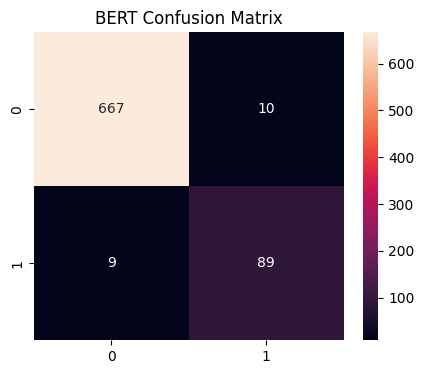

In [42]:
cm = confusion_matrix(
    bert_y_true,
    bert_y_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "BERT Confusion Matrix"
)

plt.savefig(
    "../results/figures/bert_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

## BERT Results

Final BERT Performance:

- Accuracy = 97.55%
- Precision = 89.90%
- Recall = 90.82%
- F1 Score = 90.36%

Compared with DistilBERT, BERT achieved higher precision and overall F1 Score while maintaining strong recall.

The confusion matrix demonstrates that BERT produced a more balanced trade-off between false positives and false negatives.

In [43]:
bert_model.save_pretrained(
    "../models/bert"
)

tokenizer.save_pretrained(
    "../models/bert"
)

('../models/bert\\tokenizer_config.json',
 '../models/bert\\special_tokens_map.json',
 '../models/bert\\vocab.txt',
 '../models/bert\\added_tokens.json',
 '../models/bert\\tokenizer.json')

In [44]:
transformer_results = pd.DataFrame({

    "Model":[
        "DistilBERT",
        "BERT"
    ],

    "Accuracy":[
        distilbert_accuracy,
        bert_accuracy
    ],

    "Precision":[
        distilbert_precision,
        bert_precision
    ],

    "Recall":[
        distilbert_recall,
        bert_recall
    ],

    "F1":[
        distilbert_f1,
        bert_f1
    ]

})

transformer_results

,Model,Accuracy,Precision,Recall,F1
0,DistilBERT,0.972903,0.846847,0.959184,0.899522
1,BERT,0.975484,0.898990,0.908163,0.903553


## Transformer Model Comparison

The performance of DistilBERT and BERT was compared using Accuracy, Precision, Recall, and F1 Score.

The comparison highlights the trade-off between model complexity and classification performance.

While DistilBERT offers faster training and inference, BERT provides slightly stronger predictive performance due to its larger architecture and richer contextual representations.

In [45]:
transformer_results = transformer_results.sort_values(
    by="F1",
    ascending=False
)

transformer_results

,Model,Accuracy,Precision,Recall,F1
1,BERT,0.975484,0.898990,0.908163,0.903553
0,DistilBERT,0.972903,0.846847,0.959184,0.899522


In [46]:
transformer_results.to_csv(
    "../results/transformer_results.csv",
    index=False
)

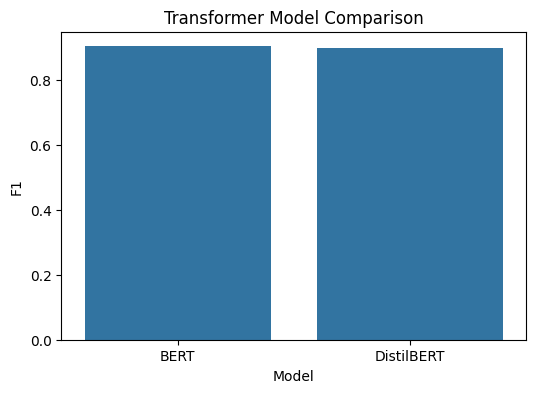

In [47]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=transformer_results,
    x="Model",
    y="F1"
)

plt.title(
    "Transformer Model Comparison"
)

plt.savefig(
    "../results/figures/transformer_comparison.png",
    bbox_inches="tight"
)

plt.show()

## Conclusion

Both transformer models achieved strong performance on the SMS spam classification task.

Summary of Results:

| Model | Accuracy | Precision | Recall | F1 Score |
|---------|---------|---------|---------|---------|
| BERT | 97.55% | 89.90% | 90.82% | 90.36% |
| DistilBERT | 97.29% | 84.68% | 95.92% | 89.95% |

BERT achieved the highest overall transformer performance and provided a better balance between precision and recall.

However, when compared with earlier experiments, transformer models did not outperform the best traditional machine learning model (Linear SVM) or the optimized LSTM model. This outcome suggests that for relatively small and highly structured datasets such as SMS spam detection, simpler models can remain highly competitive despite the increased representational power of transformer architectures.

The final notebook will combine all traditional machine learning, deep learning, and transformer results into a unified comparison framework.